# Solução de Risco de Crédito — Datarisk

**Objetivo**: estimar a probabilidade de inadimplência de contratos presentes em `base_submissao.parquet` e propor uma política de crédito.

**Target primário**: FPD5 — atraso > 5 dias na primeira parcela, em contratos com pelo menos 30 dias de maturação.  
**Target secundário**: EVER15MOB03 — usado apenas para validação de robustez do modelo.

**Decisões chave (resumo das 8 iterações de desenvolvimento)**:
- D-008: modelo único (não segmentado por tipo de contrato — volume insuficiente)
- D-010: thresholds da política derivados de percentis empíricos da PD na validação
- D-011: regra de comprometimento de renda removida (99,4% dos clientes da submissão a violaria)
- D-012: regra de cold-start mantida (afeta ~5%, gerenciável)
- D-014: calibração sigmoid (Platt) em vez de isotônica (resolve colapso de decis)
- D-015/D-016: gap val/test aceito como ruído amostral + drift; AUC sempre com IC bootstrap
- D-017: janela de treino 2020–2023 (descarta portfólio pré-COVID com perfil distinto)

## 0. Setup

In [35]:
import sys, os
# garante que o raiz do projeto está no path para importar src/
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)
print("Raiz do projeto:", ROOT)

Raiz do projeto: c:\Users\pedro\Downloads\files (3)


In [36]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
REPORT_DIR = Path("reports")
MODEL_DIR  = Path("models")

for d in [OUTPUT_DIR, REPORT_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
print("Setup concluído")

Setup concluído


## 1. Carregamento e exploração das bases

In [37]:
cadastral  = pd.read_parquet(DATA_DIR / "base_cadastral.parquet")
emprestimos = pd.read_parquet(DATA_DIR / "historico_emprestimos.parquet")
parcelas    = pd.read_parquet(DATA_DIR / "historico_parcelas.parquet")
submissao   = pd.read_parquet(DATA_DIR / "base_submissao.parquet")

print(f"base_cadastral    : {cadastral.shape}")
print(f"historico_emprestimos: {emprestimos.shape}")
print(f"historico_parcelas: {parcelas.shape}")
print(f"base_submissao    : {submissao.shape}")

FileNotFoundError: [Errno 2] No such file or directory: 'data\\base_cadastral.parquet'

In [ ]:
# inspecionar tipos e missing
def missing_report(df, name):
    pct = (df.isna().mean() * 100).round(2)
    return pd.DataFrame({"coluna": pct.index, "missing_%": pct.values, "dtype": df.dtypes.values, "base": name})

miss = pd.concat([
    missing_report(cadastral, "cadastral"),
    missing_report(emprestimos, "emprestimos"),
    missing_report(parcelas, "parcelas"),
    missing_report(submissao, "submissao"),
])
miss[miss["missing_%"] > 0].sort_values("missing_%", ascending=False).head(30)

,coluna,missing_%,dtype,base
18,taxa_juros_promocional,99.6600,float64,emprestimos
17,taxa_juros_padrao,99.6600,float64,emprestimos
5,data_liberacao,96.2000,str,emprestimos
9,data_encerramento,53.9400,str,emprestimos
15,percentual_entrada,53.6000,float64,emprestimos
14,valor_entrada,53.6000,float64,emprestimos
8,data_ultimo_vencimento,53.0300,str,emprestimos
35,acompanhantes_cliente,49.2800,str,emprestimos
7,data_ultimo_vencimento_original,45.8800,str,emprestimos
6,data_primeiro_vencimento,42.6700,str,emprestimos


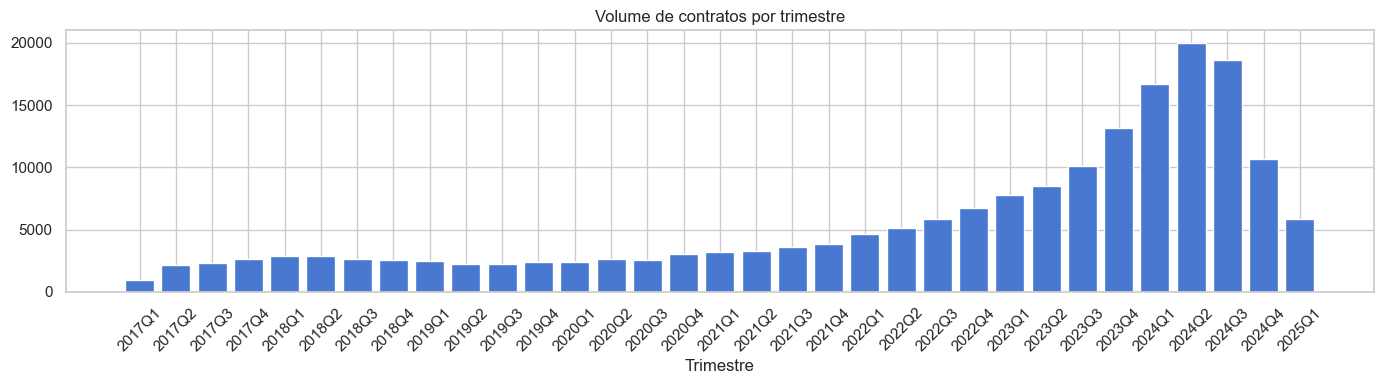

In [ ]:
# distribuição temporal dos empréstimos
emp_ts = emprestimos.copy()
emp_ts["data_decisao"] = pd.to_datetime(emp_ts["data_decisao"])
emp_ts["ano_mes"] = emp_ts["data_decisao"].dt.to_period("Q")

vol = emp_ts.groupby("ano_mes").size().reset_index(name="contratos")

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(vol["ano_mes"].astype(str), vol["contratos"])
ax.set_title("Volume de contratos por trimestre")
ax.set_xlabel("Trimestre")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(REPORT_DIR / "figures" / "vol_contratos.png", dpi=100)
plt.show()

In [ ]:
# tipos de contrato
emprestimos["tipo_contrato"].value_counts()

tipo_contrato
Cash loans         83546
Consumer loans     81684
Revolving loans    21628
XNA                   32
Name: count, dtype: int64

## 2. Pré-processamento

In [ ]:
from src.utils.io import load_config
from src.data.load_data import load_raw_data
from src.data.preprocess import preprocess
from src.data.validate_data import validate_raw_data

config = load_config("config/config.yaml")

data = load_raw_data(config)
validate_raw_data(data)
data = preprocess(data, config)

print("Bases carregadas e pré-processadas.")
print(f"emprestimos: {data['historico_emprestimos'].shape}")
print(f"parcelas   : {data['historico_parcelas'].shape}")
print(f"cadastral  : {data['base_cadastral'].shape}")
print(f"submissao  : {data['base_submissao'].shape}")

2026-05-12 16:31:53 | INFO    | src.data.load_data | lendo base_cadastral de data\base_cadastral.parquet
2026-05-12 16:31:53 | INFO    | src.data.load_data |   shape: (40000, 16)
2026-05-12 16:31:53 | INFO    | src.data.load_data | lendo base_submissao de data\base_submissao.parquet
2026-05-12 16:31:53 | INFO    | src.data.load_data |   shape: (40000, 8)
2026-05-12 16:31:53 | INFO    | src.data.load_data | lendo historico_emprestimos de data\historico_emprestimos.parquet
2026-05-12 16:31:54 | INFO    | src.data.load_data |   shape: (186890, 37)
2026-05-12 16:31:54 | INFO    | src.data.load_data | lendo historico_parcelas de data\historico_parcelas.parquet
2026-05-12 16:31:55 | INFO    | src.data.load_data |   shape: (1390978, 8)
2026-05-12 16:31:55 | INFO    | src.data.validate_data | cobertura sub->cad: 100.00%
2026-05-12 16:31:55 | INFO    | src.data.validate_data | cobertura emp->cad: 100.00%
2026-05-12 16:31:55 | INFO    | src.data.validate_data | cobertura par->emp: 100.00%
2026-0

## 3. Construção do Target

### FPD5 (primário)
**Definição**: atraso > 5 dias na **primeira parcela** do contrato.  
**Cohort**: contratos com `status_contrato == 'Approved'`, com `data_primeiro_vencimento` válida e pelo menos 30 dias de maturação antes do snapshot (`2025-02-22`).  
**Justificativa**: FPD é o sinal mais precoce de inadimplência, disponível sem censura para contratos com maturação suficiente. Gap máximo de 90 dias entre decisão e primeiro vencimento filtra anomalias cadastrais.

### EVER15MOB03 (secundário — validação de robustez)
**Definição**: atraso > 15 dias em qualquer parcela nos primeiros 3 meses do contrato.

In [ ]:
from src.target.build_target import build_targets

targets = build_targets(data["historico_emprestimos"], data["historico_parcelas"], config)

print(f"\nBase de targets: {targets.shape}")
print(f"FPD5 bad rate  : {targets['target_fpd5'].mean():.2%}  ({targets['target_fpd5'].sum():,} bads)")

ever_valid = targets[targets["target_ever15mob03"] >= 0]
print(f"EVER15MOB03 bad rate: {ever_valid['target_ever15mob03'].mean():.2%}  ({ever_valid['target_ever15mob03'].sum():,} bads)")

2026-05-12 16:31:59 | INFO    | src.target.build_target | elegíveis após filtro de gap: 107,145 -> 105,458
2026-05-12 16:31:59 | INFO    | src.target.build_target | contratos maduros para FPD5: 105,092
2026-05-12 16:31:59 | INFO    | src.target.build_target | FPD5: cohort 105,092 contratos, bad rate 1.13%, bads 1,190
2026-05-12 16:32:00 | INFO    | src.target.build_target | elegíveis após filtro de gap: 107,145 -> 105,458
2026-05-12 16:32:00 | INFO    | src.target.build_target | EVER15MOB03: cohort 102,162 contratos, bad rate 1.60%, bads 1,638

Base de targets: (105092, 5)
FPD5 bad rate  : 1.13%  (1,190 bads)
EVER15MOB03 bad rate: 1.60%  (1,638 bads)


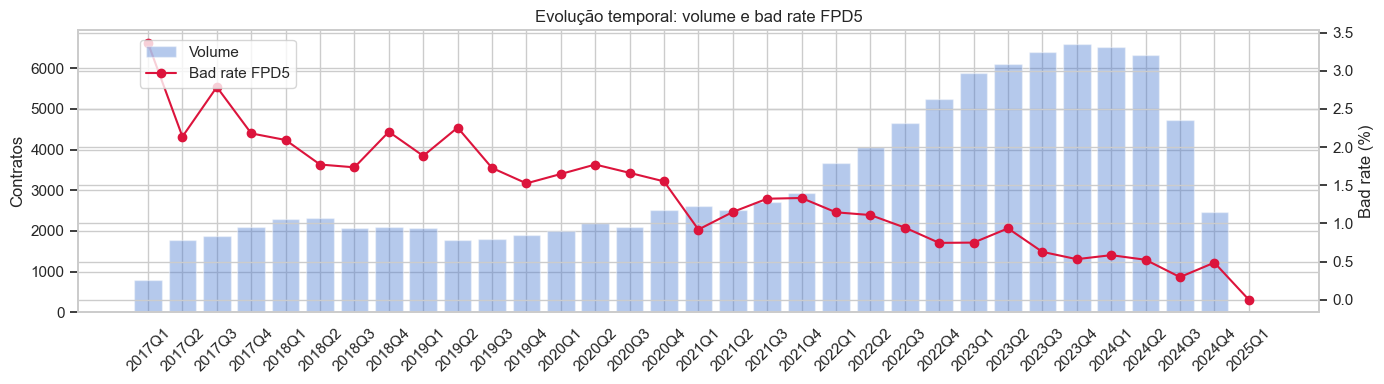

,trimestre,n,bads,bad_rate
27,2023Q4,6594,35,0.0053
28,2024Q1,6516,38,0.0058
29,2024Q2,6312,33,0.0052
30,2024Q3,4735,14,0.0030
31,2024Q4,2473,12,0.0049
32,2025Q1,8,0,0.0000


In [ ]:
# evolução temporal do bad rate FPD5
targets["data_decisao"] = pd.to_datetime(targets["data_decisao"])
targets["trimestre"] = targets["data_decisao"].dt.to_period("Q")

bad_ts = targets.groupby("trimestre").agg(
    n=("target_fpd5", "size"),
    bads=("target_fpd5", "sum")
).reset_index()
bad_ts["bad_rate"] = bad_ts["bads"] / bad_ts["n"]

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.bar(bad_ts["trimestre"].astype(str), bad_ts["n"], alpha=0.4, label="Volume")
ax2.plot(bad_ts["trimestre"].astype(str), bad_ts["bad_rate"] * 100, color="crimson", marker="o", label="Bad rate FPD5")

ax1.set_ylabel("Contratos")
ax2.set_ylabel("Bad rate (%)")
ax1.tick_params(axis="x", rotation=45)
ax1.set_title("Evolução temporal: volume e bad rate FPD5")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig(REPORT_DIR / "figures" / "bad_rate_temporal.png", dpi=100)
plt.show()

# S-02: censura em 2024 Q3/Q4 confirmada — queda de volume esperada, não problema do modelo
bad_ts.tail(6)

## 4. Engenharia de Features

In [ ]:
from src.features.build_features import build_training_applications, make_features, split_X_y

apps_train = build_training_applications(data["historico_emprestimos"], targets)

feats_train = make_features(
    apps_train,
    data["base_cadastral"],
    data["historico_emprestimos"],
    data["historico_parcelas"],
    ref_col="data_decisao",
    mode="train",
)

print(f"\nBase de features: {feats_train.shape}")

2026-05-12 16:32:06 | INFO    | src.features.build_features | [train] features cadastrais (105,092 linhas)
2026-05-12 16:32:07 | INFO    | src.features.build_features | [train] features de solicitacao
2026-05-12 16:32:07 | INFO    | src.features.build_features | [train] features de historico de contratos
2026-05-12 16:33:30 | INFO    | src.features.build_features | [train] features de pagamentos e pre-pagamento
2026-05-12 16:33:32 | INFO    | src.features.build_features | [train] base final: shape (105092, 97)

Base de features: (105092, 97)


In [ ]:
# inspecionar features geradas
from src.features.build_features import SEGMENT_NUM_COLS, SEGMENT_CAT_COLS

print(f"Features numéricas ({len(SEGMENT_NUM_COLS)}): {SEGMENT_NUM_COLS[:10]}...")
print(f"Features categóricas ({len(SEGMENT_CAT_COLS)}): {SEGMENT_CAT_COLS}")

Features numéricas (73): ['idade', 'qtd_filhos', 'qtd_membros_familia', 'renda_anual', 'renda_mensal', 'dependentes', 'dependentes_por_renda_mensal', 'filhos_por_membro', 'flag_possui_bens', 'nota_regiao_cliente']...
Features categóricas (17): ['sexo', 'tipo_renda', 'ocupacao', 'tipo_organizacao', 'nivel_educacao', 'estado_civil', 'tipo_moradia', 'possui_carro', 'possui_imovel', 'tipo_contrato', 'dia_semana_solicitacao', 'periodo_dia_solicitacao', 'faixa_idade', 'produto_mais_freq', 'canal_mais_freq', 'tipo_contrato_mais_freq', 'motivo_recusa_mais_freq']


## 5. Split Temporal

**D-017**: janela de treino restrita a `2020-01-01 → 2023-12-31` para descartar portfólio pré-COVID (2017–2019) com perfil comportamental distinto.  
Validação: `2024-01 → 2024-06` | Teste: `2024-07+`

In [ ]:
from src.models.split import temporal_split

splits = temporal_split(feats_train, config, ref_col="data_decisao")

target_col     = "target_fpd5"
secondary_col  = "target_ever15mob03"

X_tr,  num_cols, cat_cols, y_tr  = split_X_y(splits["train"], target_col=target_col)
X_val, _,        _,        y_val = split_X_y(splits["val"],   target_col=target_col)
X_te,  _,        _,        y_te  = split_X_y(splits["test"],  target_col=target_col)

y_val_sec = splits["val"][secondary_col].values
y_te_sec  = splits["test"][secondary_col].values

print(f"\n{'Split':<10} {'n':>8} {'bads':>8} {'bad rate':>10}")
for name, y in [("Treino", y_tr), ("Validação", y_val), ("Teste", y_te)]:
    print(f"{name:<10} {len(y):>8,} {int(y.sum()):>8,} {y.mean():>10.2%}")

2026-05-12 16:33:38 | INFO    | src.models.split | janela de treino restringida a partir de 2020-01-01


2026-05-12 16:33:38 | INFO    | src.models.split | split train: 62,181 contratos, periodo 2020-01-01 00:00:00 a 2023-12-31 00:00:00
2026-05-12 16:33:38 | INFO    | src.models.split | split val: 12,828 contratos, periodo 2024-01-01 00:00:00 a 2024-06-30 00:00:00
2026-05-12 16:33:38 | INFO    | src.models.split | split test: 7,216 contratos, periodo 2024-07-01 00:00:00 a 2025-01-14 00:00:00

Split             n     bads   bad rate
Treino       62,181      620      1.00%
Validação    12,828       71      0.55%
Teste         7,216       26      0.36%


## 6. Treinamento dos Modelos

**Baseline**: Regressão Logística (referência comparativa)  
**Principal**: LightGBM com regularização agressiva (M-02) para controlar o overfit observado na iteração 0 (gap treino-validação de 36 pontos).

In [ ]:
from src.models.train import train_logistic, train_lightgbm
from src.models.evaluate import evaluate_split, evaluate_by_segment, evaluate_secondary_target
from src.utils.metrics import basic_metrics

print("Treinando baseline logístico...")
baseline = train_logistic(X_tr, y_tr, num_cols, cat_cols, random_state=RANDOM_STATE)

print("Treinando LightGBM...")
lgbm = train_lightgbm(
    X_tr, y_tr, X_val, y_val,
    num_cols, cat_cols,
    lgb_params=config["model"]["lightgbm_params"],
    random_state=RANDOM_STATE,
)
print("Treinamento concluído.")

Treinando baseline logístico...
2026-05-12 16:33:46 | INFO    | src.models.train | baseline logistico treinado em 62,181 amostras
Treinando LightGBM...
2026-05-12 16:33:51 | INFO    | src.models.train | LightGBM treinado em 62,181 amostras (best iteration: 105)
Treinamento concluído.


In [ ]:
# métricas comparativas
rows = []
for nome, m in [("baseline", baseline), ("lightgbm", lgbm)]:
    for split_name, X_s, y_s in [("treino", X_tr, y_tr), ("val", X_val, y_val), ("teste", X_te, y_te)]:
        met = basic_metrics(y_s, m.predict_proba(X_s)[:, 1])
        rows.append({"modelo": nome, "split": split_name, "AUC": met["auc"], "KS": met["ks"], "LogLoss": met["log_loss"]})

metr_df = pd.DataFrame(rows)
metr_df.pivot(index=["modelo", "split"], columns=[], values=["AUC", "KS", "LogLoss"]).round(4)

AUC     KS  LogLoss
modelo   split                        
baseline treino 0.7237 0.3406   0.0521
         val    0.6385 0.2350   0.0380
         teste  0.6814 0.3550   0.0266
lightgbm treino 0.8071 0.4563   0.0498
         val    0.7100 0.3782   0.0334
         teste  0.6336 0.2896   0.0253

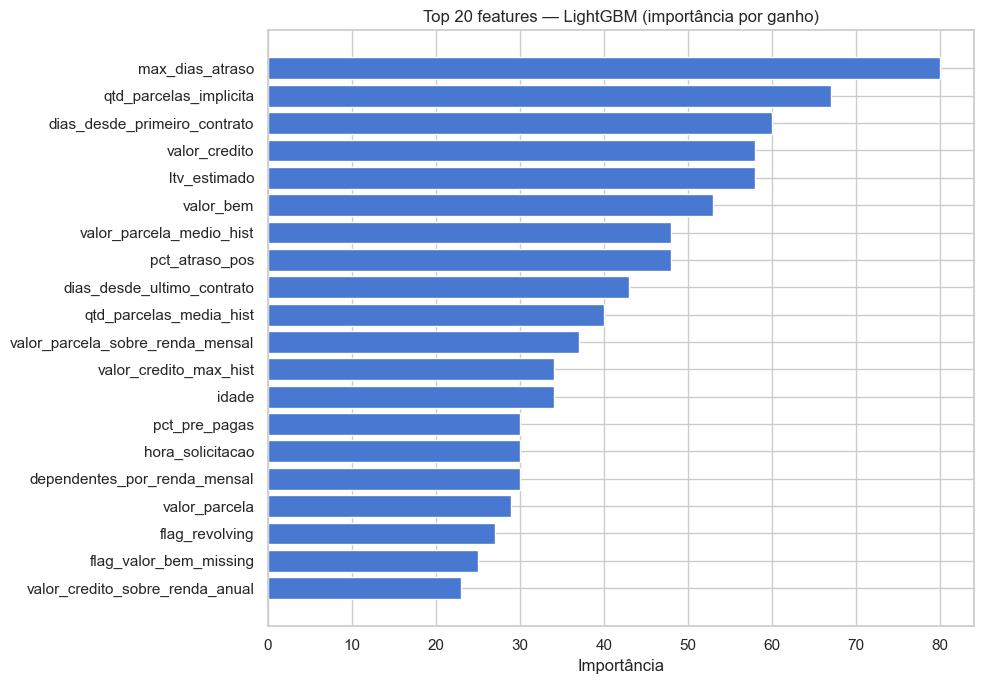

In [ ]:
# importância das features (LightGBM)
clf = lgbm.named_steps["clf"]
pre = lgbm.named_steps["pre"]

feat_names = pre.get_feature_names_out()
importances = clf.feature_importances_

imp_df = pd.DataFrame({"feature": feat_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(20)

# limpar prefixos do ColumnTransformer
imp_df["feature"] = imp_df["feature"].str.replace(r"^(num__|cat__)", "", regex=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1])
ax.set_title("Top 20 features — LightGBM (importância por ganho)")
ax.set_xlabel("Importância")
plt.tight_layout()
plt.savefig(REPORT_DIR / "figures" / "feature_importance.png", dpi=100)
plt.show()

## 7. Calibração — Platt Scaling (sigmoid)

**D-014**: calibração sigmoid (Platt) adotada em vez de isotônica.  

**Por quê não isotônica**: IsotonicRegression não-paramétrica mapeia regiões inteiras de score para o mesmo valor calibrado quando há poucos bads na validação (~71 bads). Resultado: apenas 7/10 decis únicos — modelo ranqueia mal.  

**Bug S-07 (corrigido — M-05)**: Platt original ajusta sobre o logit da probabilidade bruta, não sobre a probabilidade diretamente. Com C=1.0 padrão e bad rate de 0,55%, a regularização L2 dominava e o coeficiente ficava negativo (inversão de sinal). Solução: `C=1e6` + logit transform.

In [ ]:
from src.models.calibrate import CalibratedPipeline

calibrated = CalibratedPipeline(
    lgbm, X_val, y_val,
    method=config["model"]["calibration_method"]   # "sigmoid"
)

coef = float(calibrated.cal.coef_[0, 0])
print(f"Coeficiente Platt: {coef:.4f}  {'OK (positivo)' if coef > 0 else 'ALERTA: negativo!'}")

2026-05-12 16:35:19 | INFO    | src.models.calibrate | calibracao sigmoid aplicada com 12,828 amostras de validacao
Coeficiente Platt: 1.0768  OK (positivo)


In [ ]:
# comparar calibrações: isotônica vs sigmoid
from src.utils.metrics import basic_metrics, decile_table

cal_iso = CalibratedPipeline(lgbm, X_val, y_val, method="isotonic")
cal_sig = calibrated

for nome, cal in [("isotonic", cal_iso), ("sigmoid", cal_sig)]:
    dec = decile_table(y_te, cal.predict_proba(X_te)[:, 1])
    n_unique = dec["score_mean"].round(5).nunique()
    met = basic_metrics(y_te, cal.predict_proba(X_te)[:, 1])
    print(f"{nome:10s} → Test AUC={met['auc']:.4f}  KS={met['ks']:.4f}  decis únicos={n_unique}/10")

2026-05-12 16:35:23 | INFO    | src.models.calibrate | calibracao isotonic aplicada com 12,828 amostras de validacao
isotonic   → Test AUC=0.6365  KS=0.2904  decis únicos=7/10
sigmoid    → Test AUC=0.6336  KS=0.2896  decis únicos=10/10


## 8. Avaliação do Modelo Final

**D-016**: AUC sempre reportado com intervalo de confiança bootstrap (1000 reamostras).  
**D-015**: gap val/test aceito — o IC bootstrap mostra sobreposição; 26 bads no teste tornam o IC muito largo para detectar diferenças < 7 pts.

In [ ]:
from sklearn.metrics import roc_auc_score

def bootstrap_auc(y_true, y_score, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    aucs = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yt, ys = y_true[idx], y_score[idx]
        if len(np.unique(yt)) < 2:
            continue
        aucs.append(roc_auc_score(yt, ys))
    aucs = np.array(aucs)
    return aucs.mean(), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

print("Bootstrap AUC (1000 reamostras):\n")
for nome, X_s, y_s in [("Validação", X_val, y_val), ("Teste", X_te, y_te)]:
    proba = calibrated.predict_proba(X_s)[:, 1]
    mean_auc, lo, hi = bootstrap_auc(y_s, proba)
    bads = int(y_s.sum())
    print(f"  {nome:<12} n={len(y_s):>6,}  bads={bads:>4}  AUC={mean_auc:.4f}  IC95% [{lo:.4f}, {hi:.4f}]")

Bootstrap AUC (1000 reamostras):

  Validação    n=12,828  bads=  71  AUC=0.7112  IC95% [0.6428, 0.7794]
  Teste        n= 7,216  bads=  26  AUC=0.6346  IC95% [0.5066, 0.7495]


In [ ]:
# métricas finais consolidadas
print("\nMétricas finais (LightGBM calibrado — sigmoid + janela 2020-2023):\n")
print(f"{'Split':<12} {'AUC':>8} {'KS':>8} {'LogLoss':>10} {'n':>8} {'bads':>6} {'bad rate':>10}")
print("-" * 65)
for nome, X_s, y_s in [("Validação", X_val, y_val), ("Teste", X_te, y_te)]:
    m = basic_metrics(y_s, calibrated.predict_proba(X_s)[:, 1])
    print(f"{nome:<12} {m['auc']:>8.4f} {m['ks']:>8.4f} {m['log_loss']:>10.4f} {m['n']:>8,} {int(y_s.sum()):>6} {m['bad_rate']:>10.2%}")


Métricas finais (LightGBM calibrado — sigmoid + janela 2020-2023):

Split             AUC       KS    LogLoss        n   bads   bad rate
-----------------------------------------------------------------
Validação      0.7100   0.3782     0.0324   12,828     71      0.55%
Teste          0.6336   0.2896     0.0235    7,216     26      0.36%


In [ ]:
# métricas por segmento de tipo de contrato (teste)
seg = splits["test"]["tipo_contrato"]
print("\nAUC por tipo de contrato (teste):")
for seg_val in seg.unique():
    mask = (seg == seg_val).values
    if mask.sum() == 0:
        continue
    m = basic_metrics(y_te[mask], calibrated.predict_proba(X_te[mask])[:, 1])
    note = "(estatisticamente ruído — D-009)" if m['n'] < 200 else ""
    print(f"  {seg_val:<25} n={m['n']:>5,}  bads={int(y_te[mask].sum()):>3}  AUC={m['auc']:.4f}  {note}")


AUC por tipo de contrato (teste):
  Cash loans                n=2,343  bads=  6  AUC=0.5347  
  Consumer loans            n=4,341  bads= 14  AUC=0.5938  
  Revolving loans           n=  532  bads=  6  AUC=0.6480  


In [ ]:
# robustez: FPD5 treinado avaliado no target EVER15MOB03 (validação de robustez)
from src.models.evaluate import evaluate_secondary_target

rob_val  = evaluate_secondary_target(calibrated, X_val, y_val_sec, name="calibrated|val")
rob_test = evaluate_secondary_target(calibrated, X_te,  y_te_sec,  name="calibrated|test")

print(f"\nRobustez EVER15MOB03 — Val  AUC={rob_val.get('auc', 'nan'):.4f}  KS={rob_val.get('ks', 'nan'):.4f}")
print(f"Robustez EVER15MOB03 — Test AUC={rob_test.get('auc', 'nan'):.4f}  KS={rob_test.get('ks', 'nan'):.4f}")

2026-05-12 16:36:03 | INFO    | src.models.evaluate | [calibrated|val|robustez EVER15MOB03] n=12,828  bad_rate=0.36%  AUC=0.7159  KS=0.4100
2026-05-12 16:36:03 | INFO    | src.models.evaluate | [calibrated|test|robustez EVER15MOB03] n=4,286  bad_rate=0.07%  AUC=0.2992  KS=0.5875

Robustez EVER15MOB03 — Val  AUC=0.7159  KS=0.4100
Robustez EVER15MOB03 — Test AUC=0.2992  KS=0.5875


In [ ]:
# tabela de decis no teste
dec_table = decile_table(y_te, calibrated.predict_proba(X_te)[:, 1])
dec_table["decil"] = dec_table["decil"].astype(int)
dec_table["bad_rate"] = (dec_table["bad_rate"] * 100).round(2)
dec_table["pct_bads_acumulado"] = (dec_table["pct_bads_acumulado"] * 100).round(1)

print("\nTabela de decis — Teste:")
print(dec_table[["decil", "n", "bads", "bad_rate", "score_mean", "pct_bads_acumulado"]].to_string(index=False))

# salvar
dec_table.to_csv(REPORT_DIR / "decis_test_fpd5.csv", index=False)
n_unique_decis = dec_table["score_mean"].round(5).nunique()
print(f"\nDecis únicos: {n_unique_decis}/10")


Tabela de decis — Teste:
 decil   n  bads  bad_rate  score_mean  pct_bads_acumulado
     1 722     1    0.1400      0.0017            100.0000
     2 722     3    0.4200      0.0021             96.2000
     3 721     2    0.2800      0.0025             84.6000
     4 722     1    0.1400      0.0029             76.9000
     5 721     1    0.1400      0.0034             73.1000
     6 722     2    0.2800      0.0040             69.2000
     7 721     2    0.2800      0.0047             61.5000
     8 722     3    0.4200      0.0057             53.8000
     9 721     6    0.8300      0.0080             42.3000
    10 722     5    0.6900      0.0160             19.2000

Decis únicos: 10/10


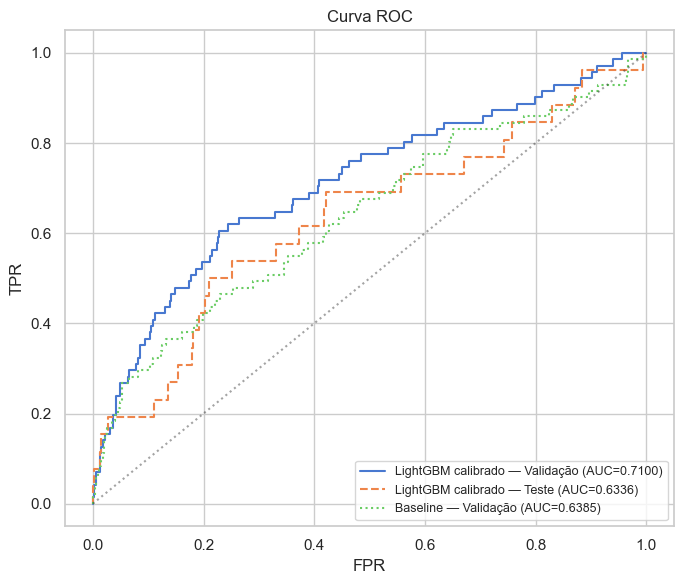

In [ ]:
# curva ROC — comparativo
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(7, 6))

for nome, X_s, y_s, ls in [
    ("LightGBM calibrado — Validação", X_val, y_val, "-"),
    ("LightGBM calibrado — Teste",     X_te,  y_te,  "--"),
    ("Baseline — Validação",           X_val, y_val, ":"),
]:
    if nome.startswith("Baseline"):
        p = baseline.predict_proba(X_s)[:, 1]
    else:
        p = calibrated.predict_proba(X_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_s, p)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, ls=ls, label=f"{nome} (AUC={roc_auc:.4f})")

ax.plot([0, 1], [0, 1], "k:", alpha=0.4)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("Curva ROC")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(REPORT_DIR / "figures" / "roc_curve.png", dpi=100)
plt.show()

### Diagnóstico: drift de features (P-02)

O gap entre validação e teste foi investigado via KS test nas top features. Drift confirmado em 13/15 features mais importantes — esperado para dados temporais com mudança de comportamento de portfólio (migração para loans de menor risco em 2024 H2).

In [ ]:
from scipy.stats import ks_2samp

X_val_df = splits["val"][[c for c in num_cols if c in splits["val"].columns]]
X_te_df  = splits["test"][[c for c in num_cols if c in splits["test"].columns]]

drift_rows = []
for col in num_cols:
    if col not in X_val_df.columns:
        continue
    a = X_val_df[col].dropna().values
    b = X_te_df[col].dropna().values
    if len(a) == 0 or len(b) == 0:
        continue
    stat, pval = ks_2samp(a, b)
    drift_rows.append({"feature": col, "ks_stat": stat, "p_value": pval})

drift_df = pd.DataFrame(drift_rows).sort_values("ks_stat", ascending=False)
drift_df["drift"] = drift_df["p_value"] < 0.001

print(f"Features com drift (p<0.001): {drift_df['drift'].sum()} / {len(drift_df)}")
print("\nTop 15 features com maior drift:")
print(drift_df.head(15).to_string(index=False))

Features com drift (p<0.001): 33 / 73

Top 15 features com maior drift:
                     feature  ks_stat  p_value  drift
         qtd_cancelados_prev   0.1488   0.0000   True
      taxa_cancelamento_hist   0.1384   0.0000   True
       qtd_contratos_previos   0.1331   0.0000   True
     qtd_parcelas_observadas   0.1320   0.0000   True
        qtd_parcelas_validas   0.1320   0.0000   True
               qtd_pre_pagas   0.1310   0.0000   True
  flag_sem_historico_credito   0.1241   0.0000   True
flag_sem_historico_pagamento   0.1234   0.0000   True
          qtd_aprovados_prev   0.1231   0.0000   True
           qtd_contratos_12m   0.1120   0.0000   True
         taxa_aprovacao_hist   0.0972   0.0000   True
      qtd_parcelas_implicita   0.0947   0.0000   True
dias_desde_primeiro_contrato   0.0787   0.0000   True
            qtd_contratos_6m   0.0760   0.0000   True
    flag_perfil_disciplinado   0.0741   0.0000   True


## 9. Política de Crédito

**D-010**: thresholds derivados de percentis empíricos da PD na validação (q70, q90, q97), não absolutos.  
**D-011**: regra de comprometimento de renda (`valor_parcela / renda_mensal > 40%`) removida — 99,4% dos clientes da submissão têm comprometimento > 40% (escala do dataset adaptado de Home Credit não reflete padrões brasileiros).  
**D-012**: cold-start (`flag_sem_historico_credito == 1`) rebaixa verde → amarela (~5% da base).

In [ ]:
from src.features.build_features import build_scoring_applications

apps_score = build_scoring_applications(data["base_submissao"])
feats_score = make_features(
    apps_score,
    data["base_cadastral"],
    data["historico_emprestimos"],
    data["historico_parcelas"],
    ref_col="data_solicitacao",
    mode="score",
)

print(f"Base de submissão para score: {feats_score.shape}")

2026-05-12 16:36:47 | INFO    | src.features.build_features | [score] features cadastrais (40,000 linhas)
2026-05-12 16:36:47 | INFO    | src.features.build_features | [score] features de solicitacao
2026-05-12 16:36:47 | INFO    | src.features.build_features | [score] features de historico de contratos
2026-05-12 16:37:27 | INFO    | src.features.build_features | [score] features de pagamentos e pre-pagamento
2026-05-12 16:37:27 | INFO    | src.features.build_features | [score] base final: shape (40000, 93)
Base de submissão para score: (40000, 93)


In [ ]:
from src.models.predict import generate_submission

X_score, _, _, _ = split_X_y(feats_score)

submission_path = str(OUTPUT_DIR / "submissao_case.csv")
submission = generate_submission(
    calibrated, X_score, feats_score["id_cliente"], submission_path
)

print(f"\nSubmissão gerada: {submission.shape}")
print(f"PD média  : {submission['probabilidade_inadimplencia'].mean():.4f}")
print(f"PD mediana: {submission['probabilidade_inadimplencia'].median():.4f}")
print(f"PD máx    : {submission['probabilidade_inadimplencia'].max():.4f}")
submission.head()

2026-05-12 16:37:29 | INFO    | src.models.predict | submissao salva em outputs\submissao_case.csv | linhas: 40,000 | PD media: 0.0042 | PD mediana: 0.0029

Submissão gerada: (40000, 2)
PD média  : 0.0042
PD mediana: 0.0029
PD máx    : 0.0591


,id_cliente,probabilidade_inadimplencia
0,100023,0.0024
1,100031,0.0031
2,100056,0.0059
3,100069,0.0020
4,100085,0.0021


In [ ]:
from src.policy.credit_policy import build_policy_output

pd_val_arr = calibrated.predict_proba(X_val)[:, 1]
policy_path = str(OUTPUT_DIR / "decisoes_credito_simuladas.csv")

policy_df, thresholds = build_policy_output(
    submission,
    data["base_submissao"],
    feats_score,
    pd_val_arr,
    config,
    policy_path,
)

print(f"\nThresholds derivados da validação:")
print(f"  t_low  (q{thresholds['q_low']:.0%}) = {thresholds['t_low']:.4f}")
print(f"  t_med  (q{thresholds['q_med']:.0%}) = {thresholds['t_med']:.4f}")
print(f"  t_high (q{thresholds['q_high']:.0%}) = {thresholds['t_high']:.4f}")

2026-05-12 16:37:33 | INFO    | src.policy.credit_policy | thresholds derivados (val): t_low=0.0055 (q70%), t_med=0.0107 (q90%), t_high=0.0168 (q97%)
2026-05-12 16:37:34 | INFO    | src.policy.credit_policy | saida de politica salva em outputs\decisoes_credito_simuladas.csv
2026-05-12 16:37:34 | INFO    | src.policy.credit_policy | resumo da politica:
  decisao_sugerida     n  pd_media  valor_credito_total     pct
    analise_manual  2022    0.0131       597878455.5000  5.0600
aprovar_automatico 30953    0.0028     19319734656.0000 77.3800
aprovar_com_ajuste  6523    0.0065      3381078739.5000 16.3100
          rejeitar   502    0.0230       151694941.5000  1.2600
2026-05-12 16:37:34 | INFO    | src.policy.credit_policy | distribuicao por faixa:
faixa_risco     n     pct
      verde 30953 77.3800
    amarela  6523 16.3100
    laranja  2022  5.0600
   vermelha   502  1.2600

Thresholds derivados da validação:
  t_low  (q70%) = 0.0055
  t_med  (q90%) = 0.0107
  t_high (q97%) = 0.0168


In [ ]:
# resumo da política
summary = policy_df.groupby("decisao_sugerida").agg(
    n=("id_cliente", "size"),
    pd_media=("probabilidade_inadimplencia", "mean"),
    valor_credito_total=("valor_credito", "sum"),
).reset_index()
summary["pct"] = (summary["n"] / len(policy_df) * 100).round(2)
summary["valor_credito_bi"] = (summary["valor_credito_total"] / 1e9).round(2)
summary["pd_media"] = (summary["pd_media"] * 100).round(3)

ordem = ["aprovar_automatico", "aprovar_com_ajuste", "analise_manual", "rejeitar"]
summary["decisao_sugerida"] = pd.Categorical(summary["decisao_sugerida"], categories=ordem, ordered=True)
summary = summary.sort_values("decisao_sugerida")

print("\nResumo da política de crédito:\n")
print(summary[["decisao_sugerida", "n", "pct", "pd_media", "valor_credito_bi"]].to_string(index=False))


Resumo da política de crédito:

  decisao_sugerida     n     pct  pd_media  valor_credito_bi
aprovar_automatico 30953 77.3800    0.2780           19.3200
aprovar_com_ajuste  6523 16.3100    0.6450            3.3800
    analise_manual  2022  5.0600    1.3110            0.6000
          rejeitar   502  1.2600    2.2950            0.1500


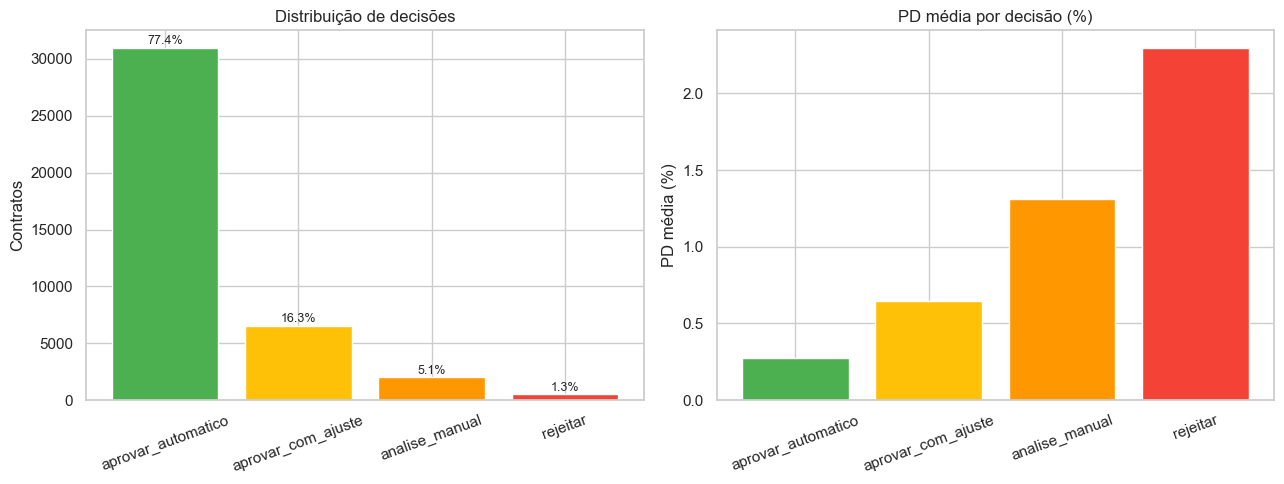

In [ ]:
# visualização da política
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# distribuição de decisões
cores = {"aprovar_automatico": "#4CAF50", "aprovar_com_ajuste": "#FFC107",
         "analise_manual": "#FF9800", "rejeitar": "#F44336"}
ax = axes[0]
bars = ax.bar(summary["decisao_sugerida"], summary["n"],
               color=[cores[d] for d in summary["decisao_sugerida"]])
ax.set_title("Distribuição de decisões")
ax.set_ylabel("Contratos")
ax.tick_params(axis="x", rotation=20)
for bar, pct in zip(bars, summary["pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

# PD média por faixa
ax2 = axes[1]
ax2.bar(summary["decisao_sugerida"], summary["pd_media"],
        color=[cores[d] for d in summary["decisao_sugerida"]])
ax2.set_title("PD média por decisão (%)")
ax2.set_ylabel("PD média (%)")
ax2.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(REPORT_DIR / "figures" / "politica_credito.png", dpi=100)
plt.show()

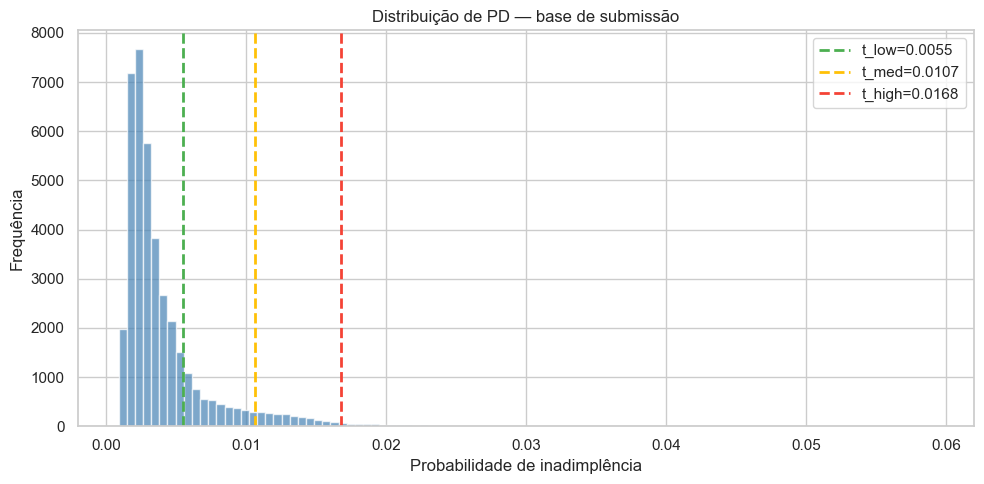

In [ ]:
# distribuição de PD na submissão com faixas de risco
fig, ax = plt.subplots(figsize=(10, 5))

pd_vals = submission["probabilidade_inadimplencia"].values
ax.hist(pd_vals, bins=100, color="steelblue", alpha=0.7)

for nome, tval, cor in [
    ("t_low", thresholds["t_low"], "#4CAF50"),
    ("t_med", thresholds["t_med"], "#FFC107"),
    ("t_high", thresholds["t_high"], "#F44336"),
]:
    ax.axvline(tval, color=cor, lw=2, ls="--", label=f"{nome}={tval:.4f}")

ax.set_title("Distribuição de PD — base de submissão")
ax.set_xlabel("Probabilidade de inadimplência")
ax.set_ylabel("Frequência")
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "figures" / "distribuicao_pd.png", dpi=100)
plt.show()

## 10. Persistência e Validação Final

In [ ]:
from src.models.train import save_model
from src.models.evaluate import save_metrics
import json

# salvar modelo
save_model(lgbm, str(MODEL_DIR / "lightgbm.joblib"))

# salvar métricas
metrics_final = {}
for split_name, X_s, y_s in [("val", X_val, y_val), ("test", X_te, y_te)]:
    metrics_final[f"calibrated_{split_name}"] = basic_metrics(y_s, calibrated.predict_proba(X_s)[:, 1])

metrics_final["policy_thresholds"] = thresholds
save_metrics(metrics_final, str(REPORT_DIR / "metricas_modelo.json"))

print("Modelo e métricas salvos.")

2026-05-12 16:38:14 | INFO    | src.models.train | modelo salvo em models\lightgbm.joblib
2026-05-12 16:38:14 | INFO    | src.models.evaluate | metricas salvas em reports\metricas_modelo.json
Modelo e métricas salvos.


In [ ]:
# validar arquivo de submissão
sub_check = pd.read_csv(OUTPUT_DIR / "submissao_case.csv")

assert list(sub_check.columns) == ["id_cliente", "probabilidade_inadimplencia"], \
    "Colunas incorretas no arquivo de submissão"
assert sub_check["probabilidade_inadimplencia"].between(0, 1).all(), \
    "Probabilidades fora do intervalo [0, 1]"
assert sub_check["id_cliente"].nunique() == len(sub_check), \
    "IDs duplicados na submissão"

expected_ids = set(data["base_submissao"]["id_cliente"])
actual_ids   = set(sub_check["id_cliente"])
assert expected_ids == actual_ids, \
    f"Clientes faltando ou extras: {len(expected_ids - actual_ids)} faltando, {len(actual_ids - expected_ids)} extras"

print(f"Submissão validada com sucesso:")
print(f"  Linhas      : {len(sub_check):,}")
print(f"  Colunas     : {list(sub_check.columns)}")
print(f"  PD min/max  : {sub_check['probabilidade_inadimplencia'].min():.6f} / {sub_check['probabilidade_inadimplencia'].max():.6f}")
print(f"  PD média    : {sub_check['probabilidade_inadimplencia'].mean():.4f}")
print(f"  PD mediana  : {sub_check['probabilidade_inadimplencia'].median():.4f}")

Submissão validada com sucesso:
  Linhas      : 40,000
  Colunas     : ['id_cliente', 'probabilidade_inadimplencia']
  PD min/max  : 0.000900 / 0.059061
  PD média    : 0.0042
  PD mediana  : 0.0029


## Resumo das decisões técnicas

| ID | Decisão |
|----|---------|
| D-008 | Modelo único — volume insuficiente para treino segmentado por tipo de contrato |
| D-009 | AUC de Cash loans no teste não é métrica de seleção (IC ≈ ±0.18, estatisticamente ruído) |
| D-010 | Thresholds da política derivados de percentis empíricos da PD na validação (q70/q90/q97) |
| D-011 | Regra de comprometimento removida (99,4% dos clientes violariam — escala incompatível) |
| D-012 | Regra cold-start mantida: verde → amarela para clientes sem histórico |
| D-014 | Calibração sigmoid (Platt) em vez de isotônica — resolve colapso de decis (10/10 vs 7/10) |
| D-015 | Gap val/test aceito: ruído amostral (26 bads, IC largo) + drift estrutural confirmado |
| D-016 | AUC reportado com IC bootstrap em todas as comunicações |
| D-017 | Janela de treino: 2020-01-01 → 2023-12-31 (descarta portfólio pré-COVID) |